# CAP-02 / CAP-03: frozen synthetic holdout
**AWS ML Engineering · 9 October 2026**

Owner-approved synthetic benchmark: 120 AI-authored/AI-reviewed messages, 30 per language and 12 per intent. Models, prompt and labels were frozen before evaluation; no post-test tuning. This is **not independently collected human data**, a population estimate, or a shopping-action safety test. Historical development results remain in `cap03-model-comparison.ipynb`.

Run All only reads local evidence and displays results. It never loads model binaries, trains, downloads weights or calls an API.

In [1]:
import hashlib, html, json
from pathlib import Path
from IPython.display import HTML, Image, Markdown, display
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "eval/datasets/capstone-v1").exists())
evidence = root / "eval/evidence/cap03-holdout-20261009"
report = json.loads((evidence / "report.json").read_text(encoding="utf-8"))
release_path = root / "eval/datasets/capstone-v1/holdout-20261009/release.json"
release = json.loads(release_path.read_text(encoding="utf-8"))
def sha(path): return hashlib.sha256(path.read_bytes()).hexdigest()
assert sha(release_path) == report["binding"]["release_sha256"]
for name in ["protocol", "records", "review", "overlap"]:
    assert sha(root / release[name]) == release[name + "_sha256"]
records = json.loads((root / release["records"]).read_text(encoding="utf-8"))
assert len(records) == 120
local = json.loads((evidence / "offline.json").read_text(encoding="utf-8"))
assert local["binding"] == report["binding"]
paid = report["paid_ledger"]
assert paid["binding"] == report["binding"]
rows = {name: {key: value["prediction"] for key,value in result["attempts"].items()}
        for name,result in local["families"].items()}
rows["llm"] = {key:value.get("result",{}).get("prediction","__failure__") for key,value in paid["attempts"].items()}
for name, result in report["results"].items():
    correct = sum(rows.get(name,{}).get(r["case_id"]) == r["expected"]["intent"] for r in records)
    assert abs(result["accuracy"] - correct / len(records)) < 1e-12
    assert sum(map(sum,result["confusion_matrix"])) == 120
    m=result["confusion_matrix"]
    f1=[2*m[i][i]/(sum(m[i])+sum(row[i] for row in m)) if sum(m[i])+sum(row[i] for row in m) else 0 for i in range(10)]
    assert abs(sum(f1)/10-result["macro_f1"]) < 1e-12
print("Release hashes, input counts, accuracy, macro-F1 and denominators verified.")
def table(headers, data):
    display(HTML("<table><tr>"+"".join("<th>"+html.escape(str(h))+"</th>" for h in headers)+"</tr>"+
        "".join("<tr>"+"".join("<td>"+html.escape(str(v))+"</td>" for v in row)+"</tr>" for row in data)+"</table>"))

Release hashes, input counts, accuracy, macro-F1 and denominators verified.


## Same-input comparison
All eight contenders classify the same text into the same ten labels. Invalid outputs and missing attempts remain in the denominator. Differences between previous validation scores and this new set are not a controlled improvement.

Model,Correct / 120,Accuracy,Macro-F1,Failures,Missing attempts
lr,69,57.50%,0.5646,0,0
svm,63,52.50%,0.4864,0,0
nb,74,61.67%,0.5837,0,0
rf,46,38.33%,0.3664,0,0
xgb,40,33.33%,0.3268,0,0
embedding_lr,59,49.17%,0.4702,0,0
embedding_mlp,55,45.83%,0.4259,0,0
llm,120,100.00%,1.0,0,0


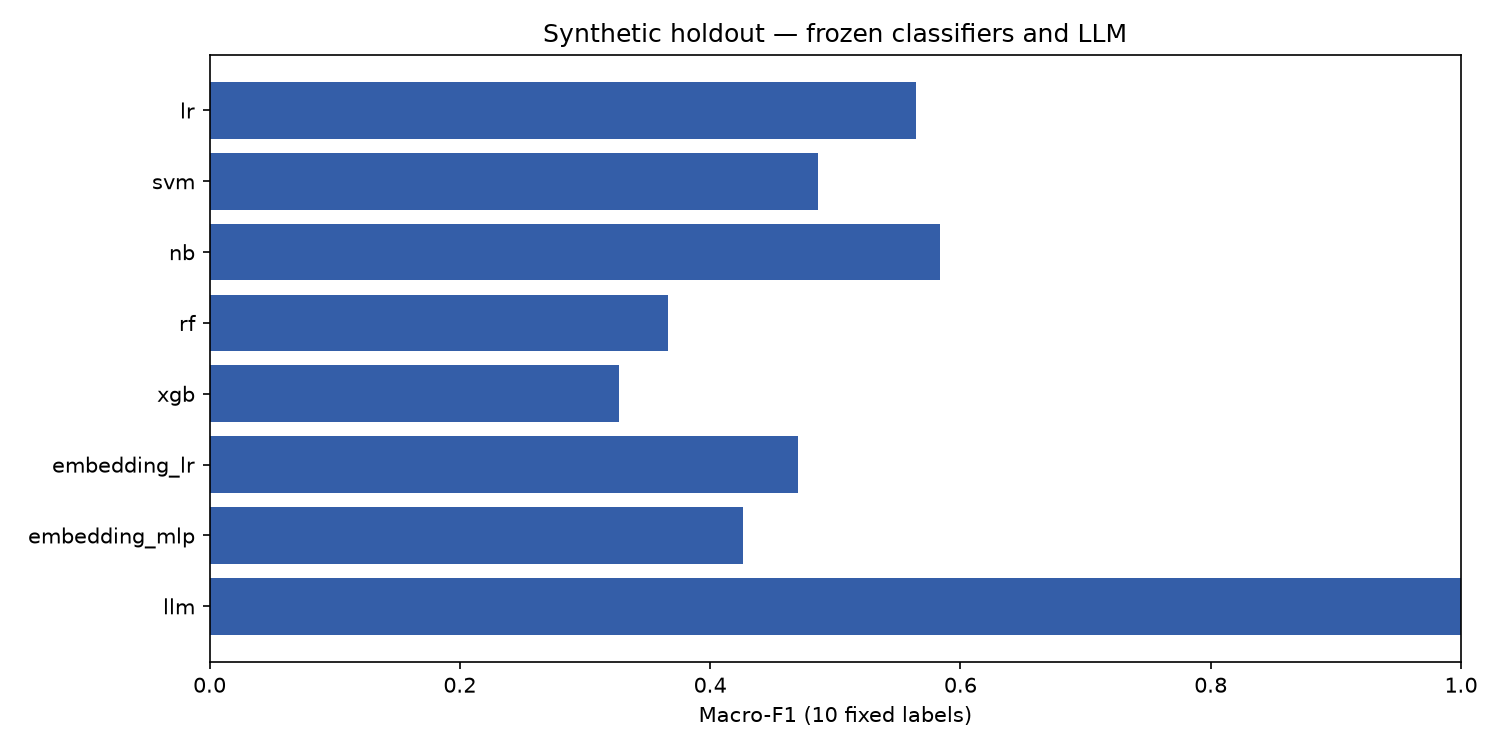

In [2]:
table(["Model","Correct / 120","Accuracy","Macro-F1","Failures","Missing attempts"],
 [[name,round(r["accuracy"]*120),f"{r['accuracy']:.2%}",round(r["macro_f1"],4),r["failure_count"],len(r["missing_attempts"])] for name,r in report["results"].items()])
display(Image(filename=str(evidence / "figures/comparison.png")))

## Language slices
Thirty synthetic messages per language. These small, authored slices do not establish performance on real shoppers.

In [3]:
table(["Model","Language","n","Accuracy","Macro-F1"],[[name,lang,s["count"],f"{s['accuracy']:.2%}",round(s["macro_f1"],4)]
 for name,r in report["results"].items() for lang,s in r["per_language"].items()])

Model,Language,n,Accuracy,Macro-F1
lr,egyptian_arabic,30,70.00%,0.6795
lr,franco_arabic,30,56.67%,0.5619
lr,english,30,46.67%,0.4738
lr,mixed,30,56.67%,0.5361
svm,egyptian_arabic,30,56.67%,0.5395
svm,franco_arabic,30,46.67%,0.4385
svm,english,30,46.67%,0.429
svm,mixed,30,60.00%,0.5379
nb,egyptian_arabic,30,63.33%,0.6188
nb,franco_arabic,30,50.00%,0.4238


## Inspect all errors
Change `selected_model` to any model key. Labels were finalized before predictions and are not rewritten to improve scores.

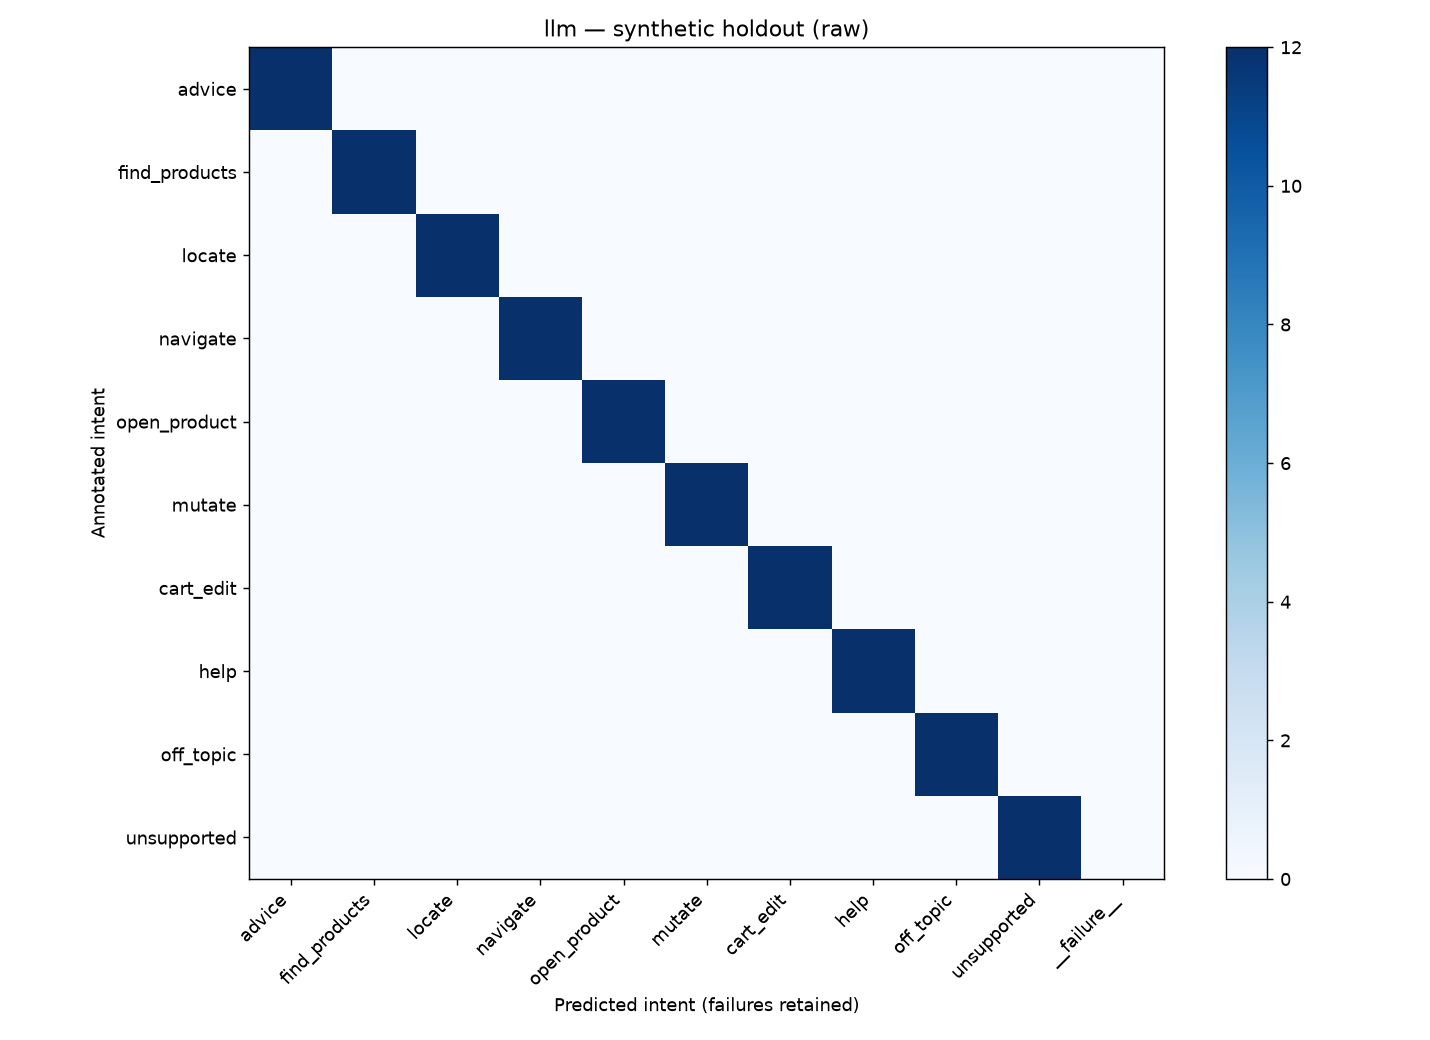

ID,Language,Message,Annotated,Predicted


In [4]:
selected_model = "llm"
display(Image(filename=str(evidence / f"figures/{selected_model}-raw.png")))
errors=[r for r in records if rows.get(selected_model,{}).get(r["case_id"]) != r["expected"]["intent"]]
table(["ID","Language","Message","Annotated","Predicted"], [[r["case_id"],r["language_group"],r["input"]["message"],r["expected"]["intent"],rows.get(selected_model,{}).get(r["case_id"],"__failure__")] for r in errors])

## Latency and cost
Local measurements include fresh text processing (and encoder for embedding heads), after one non-test warm-up. LLM timings include network/key checks. They are single-request label classification, not full shopping-task timings. Local electricity/hardware cost was not measured. Training timings/configurations remain in the earlier reports; no models were retrained.

In [5]:
table(["Model","Timing samples","p50 ms","p95 ms"],[[n,r["latency_ms"]["sample_count"],r["latency_ms"]["p50"],r["latency_ms"]["p95"]] for n,r in report["results"].items()])
print("Paid spent plus unresolved reservations:",paid["spent_plus_reserved_usd"])
print("Experiment cap:",paid["cap_usd"])
print("Unknown costs:",sum(a["actual_cost_usd"] is None for a in paid["attempts"].values()))
display(local["environment"])

Model,Timing samples,p50 ms,p95 ms
lr,120,0.9165499999994609,1.2556949999918743
svm,120,0.7921000000123968,1.1877100000049268
nb,120,0.945150000063677,1.2663899999552086
rf,120,24.270750000027874,25.074809999915715
xgb,120,1.4701499999887346,1.7766799999662908
embedding_lr,120,15.019100000017716,17.342165000093246
embedding_mlp,120,14.896900000053392,17.632800000069437
llm,120,1476.8602999999985,4159.357265000026


Paid spent plus unresolved reservations: 0.0148178
Experiment cap: 0.20
Unknown costs: 0


{'python': '3.12.5',
 'platform': 'Windows-11-10.0.26300-SP0',
 'processor': 'Intel64 Family 6 Model 151 Stepping 5, GenuineIntel',
 'cpu_count': 12,
 'threads': 4,
 'device': 'cpu',
 'packages': {'scikit-learn': '1.9.1',
  'numpy': '2.5.3',
  'scipy': '1.18.1',
  'joblib': '1.6.0',
  'xgboost': '3.4.1',
  'torch': '2.14.1+cu130',
  'sentence-transformers': '6.1.0',
  'transformers': '5.19.0',
  'huggingface-hub': '1.33.0'}}

## Reproduction and limitations
See `docs/cap02-cap03-closeout.md` for commands, scope amendment, provenance, review and overlap limits. Earlier training/validation releases remain immutable. Reusing this consumed holdout to tune future models would make later scores development evidence. The LLM has broad pretraining and gets label definitions; classifiers learned the task from labeled training examples. This is equal per-case input, not equal pretraining or supervision.